In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Project paths
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

# Load cleaned datasets
users = pd.read_csv(DATA_DIR / "cleaned_users.csv")
posts = pd.read_csv(DATA_DIR / "cleaned_posts.csv")

# Convert dates/timestamps back to datetime
users["account_created"] = pd.to_datetime(users["account_created"])
posts["timestamp"] = pd.to_datetime(posts["timestamp"])

print("Users shape:", users.shape)
print("Posts shape:", posts.shape)

Users shape: (1500, 5)
Posts shape: (12000, 13)


In [2]:
# Basic dataset overview

print("USERS")
display(users.head())

print("\nPOSTS")
display(posts.head())

print("\nUser data types:")
display(users.dtypes)

print("\nPost data types:")
display(posts.dtypes)

USERS


,user_id,location,language,account_created,follower_count
0,user_guglt5jp,"Berlin, Germany",ja,2023-10-23,38963
1,user_b1p3wz81,"Munich, Germany",zh,2023-05-06,24644
2,user_jm2grmis,"Dubai, UAE",en,2023-01-03,45842
3,user_ykoqww5l,"Paris, France",fr,2023-10-11,665
4,user_3zzvv8vp,"Los Angeles, USA",ru,2023-05-23,42908



POSTS


,post_id,user_id,platform,text_content,timestamp,likes,shares,comments,engagement,platform_was_missing,text_was_missing,likes_was_missing,likes_was_invalid
0,to64mgey2v3y,user_vfxs1pry,Reddit,Bummed out with my new Air Max from Nike! Abso...,2024-09-25 00:00:00,4488.0,1456,673,6617.0,False,False,False,False
1,7f0wdauzbj89,user_8l7rv5oe,Reddit,My one month review of Pepsi Crystal Pepsi: Hi...,2024-08-01 16:14:00,789.0,1484,39,2312.0,False,False,False,False
2,dvvhg8eel45x,user_nfo3ih5u,Unknown,Just unboxed my new Highlander from Toyota. Ex...,2025-04-13 20:12:18,NaN,1410,839,NaN,True,False,True,False
3,hgb9cxke4t7b,user_27aje6ur,Facebook,Comparing Pepsi Crystal Pepsi to the competiti...,2024-09-10 00:00:00,167.0,584,833,1584.0,False,False,False,False
4,zwerpw3wk320,user_9px5q0by,Reddit,My one week review of Coca-Cola Diet Coke: Bes...,2024-05-31 00:00:00,4749.0,152,630,5531.0,False,False,False,False



User data types:


user_id                       str
location                      str
language                      str
account_created    datetime64[us]
follower_count              int64
dtype: object


Post data types:


post_id                            str
user_id                            str
platform                           str
text_content                       str
timestamp               datetime64[us]
likes                          float64
shares                           int64
comments                         int64
engagement                     float64
platform_was_missing              bool
text_was_missing                  bool
likes_was_missing                 bool
likes_was_invalid                 bool
dtype: object

# 1. User Demographics and Follower Distribution

This section examines the composition of the Social Engine user base using
language, location, and follower-count distributions.

The objective is to identify dominant user segments and understand whether
audience size is evenly distributed or concentrated among a smaller group of
users.

In [3]:
# User demographic overview

print("Number of unique users:", users["user_id"].nunique())
print("Number of languages:", users["language"].nunique())
print("Number of locations:", users["location"].nunique())

print("\nLanguage distribution:")
display(
    users["language"]
    .value_counts()
    .rename_axis("language")
    .reset_index(name="user_count")
)

print("\nTop 10 locations:")
display(
    users["location"]
    .value_counts()
    .head(10)
    .rename_axis("location")
    .reset_index(name="user_count")
)

print("\nFollower statistics:")
display(
    users["follower_count"]
    .describe()
    .to_frame("follower_count")
)

Number of unique users: 1500
Number of languages: 10
Number of locations: 33

Language distribution:


,language,user_count
0,zh,168
1,ja,156
2,hi,156
3,en,153
4,fr,150
5,es,146
6,ru,144
7,ar,143
8,pt,143
9,de,141



Top 10 locations:


,location,user_count
0,"Barcelona, Spain",56
1,"Shanghai, China",56
2,"Los Angeles, USA",55
3,"Munich, Germany",54
4,"Dubai, UAE",53
5,"Mumbai, India",53
6,"Milan, Italy",53
7,"Melbourne, Australia",52
8,"Beijing, China",51
9,"Houston, USA",50



Follower statistics:


,follower_count
count,1500.000000
mean,24964.019333
std,14185.477457
min,109.000000
25%,12771.750000
50%,24741.500000
75%,37097.250000
max,49944.000000


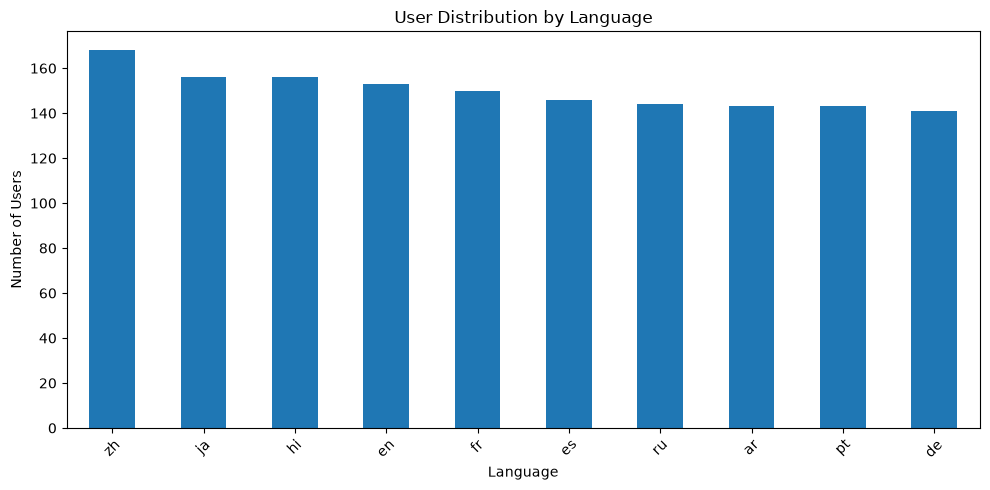

In [4]:
# Language distribution

language_counts = users["language"].value_counts()

plt.figure(figsize=(10, 5))
language_counts.plot(kind="bar")
plt.title("User Distribution by Language")
plt.xlabel("Language")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

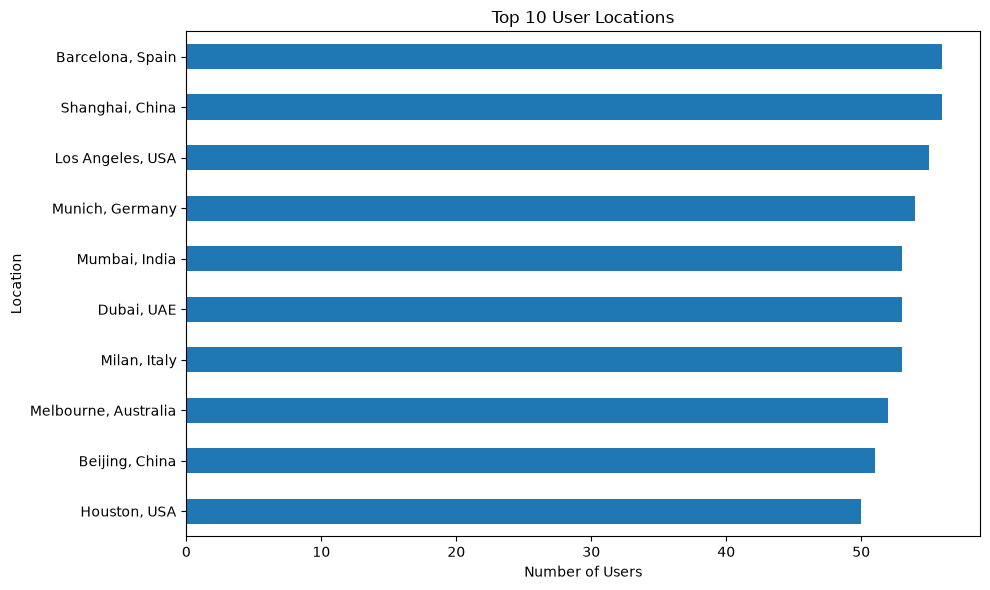

In [5]:
# Top 10 locations

location_counts = users["location"].value_counts().head(10)

plt.figure(figsize=(10, 6))
location_counts.sort_values().plot(kind="barh")
plt.title("Top 10 User Locations")
plt.xlabel("Number of Users")
plt.ylabel("Location")
plt.tight_layout()
plt.show()

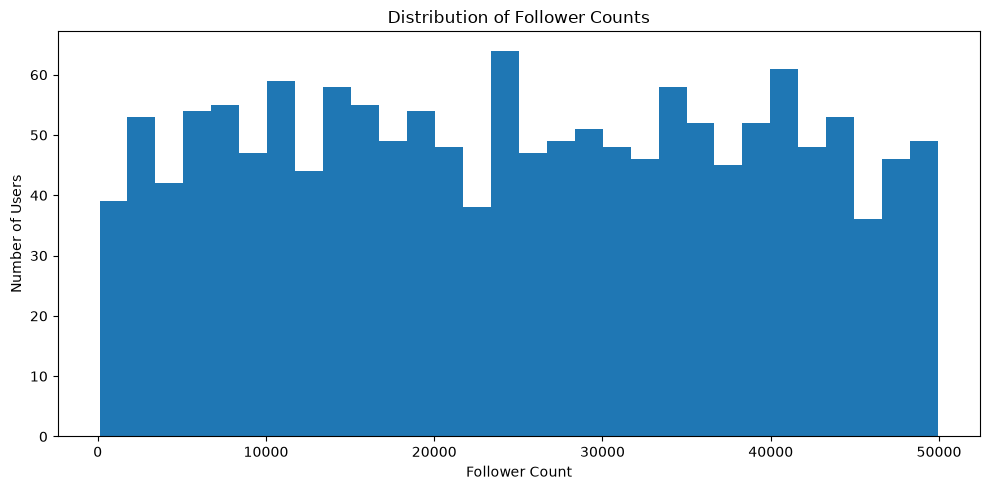

In [6]:
# Follower-count distribution

plt.figure(figsize=(10, 5))
plt.hist(
    users["follower_count"],
    bins=30
)
plt.title("Distribution of Follower Counts")
plt.xlabel("Follower Count")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()

## Key Findings — User Demographics

### Language diversity

The 1,500-user dataset is distributed across 10 languages. The largest
language group is Chinese (`zh`) with 168 users (11.2%), while German (`de`)
is the smallest with 141 users (9.4%). The relatively small difference between
the largest and smallest groups indicates that the user base is highly
balanced across languages rather than dominated by a single language.

### Geographic diversity

Users are distributed across 33 locations. Barcelona and Shanghai have the
highest representation with 56 users each, corresponding to approximately
3.7% of the total user base per location. No individual location therefore
dominates the dataset.

### Follower distribution

Follower counts range from 109 to 49,944. The mean follower count is
approximately 24,964 while the median is approximately 24,742. The close
relationship between these two measures suggests that the follower-count
distribution is not strongly shifted by a small number of extremely large
accounts.

The histogram shows users distributed broadly across the available follower
range. No strong concentration at the lower or upper boundary is visually
apparent.

# 2. Post Activity and Platform Analysis

This section examines how posts are distributed across platforms and over
time.

The analysis focuses on:
- platform usage
- posting volume over time
- monthly activity patterns
- the proportion of posts whose platform was unavailable in the recovered data

In [14]:
# Platform distribution

platform_counts = (
    posts["platform"]
    .value_counts()
    .rename_axis("platform")
    .reset_index(name="post_count")
)

platform_counts["percentage"] = (
    platform_counts["post_count"] / len(posts) * 100
).round(2)

display(platform_counts)

,platform,post_count,percentage
0,Facebook,2074,17.28
1,YouTube,2073,17.27
2,Twitter,2049,17.08
3,Reddit,2031,16.92
4,Instagram,1989,16.58
5,Unknown,1784,14.87


<Figure size 1000x600 with 0 Axes>

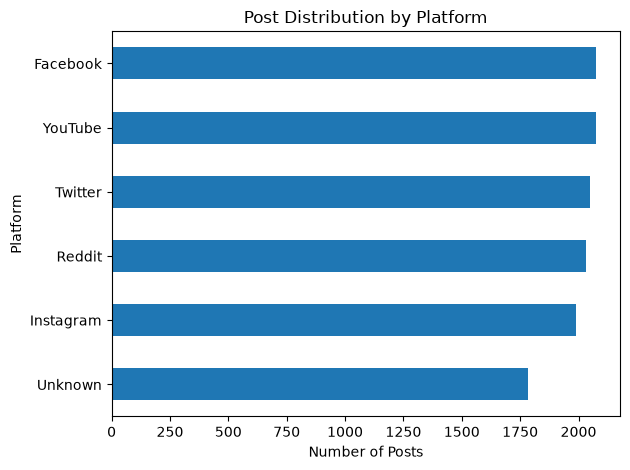

In [15]:
# Platform distribution chart

plt.figure(figsize=(10, 6))

platform_counts.sort_values("post_count").plot(
    x="platform",
    y="post_count",
    kind="barh",
    legend=False,
)

plt.title("Post Distribution by Platform")
plt.xlabel("Number of Posts")
plt.ylabel("Platform")
plt.tight_layout()
plt.show()

In [16]:
# Monthly posting volume

monthly_posts = (
    posts.set_index("timestamp")
    .resample("ME")
    .size()
    .rename("post_count")
)

display(monthly_posts.to_frame())

,post_count
timestamp,
2024-05-31,1038
2024-06-30,979
2024-07-31,996
2024-08-31,1015
2024-09-30,974
2024-10-31,1029
2024-11-30,1025
2024-12-31,1035
2025-01-31,1007


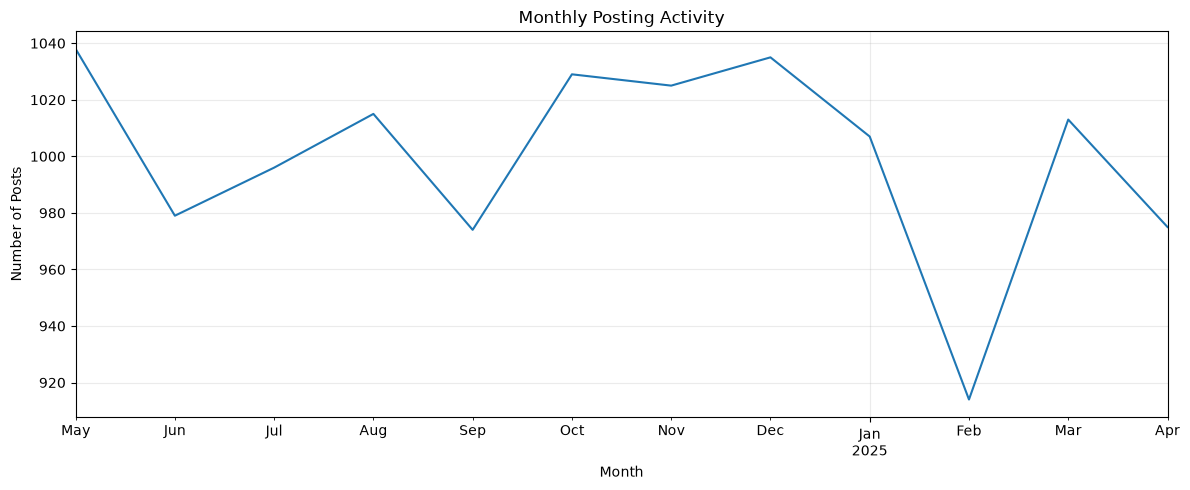

In [17]:
# Monthly posting activity

plt.figure(figsize=(12, 5))

monthly_posts.plot()

plt.title("Monthly Posting Activity")
plt.xlabel("Month")
plt.ylabel("Number of Posts")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [18]:
# Daily posting volume

daily_posts = (
    posts.set_index("timestamp")
    .resample("D")
    .size()
)

print("Average posts per day:", round(daily_posts.mean(), 2))
print("Minimum posts on a day:", daily_posts.min())
print("Maximum posts on a day:", daily_posts.max())

Average posts per day: 32.88
Minimum posts on a day: 18
Maximum posts on a day: 54


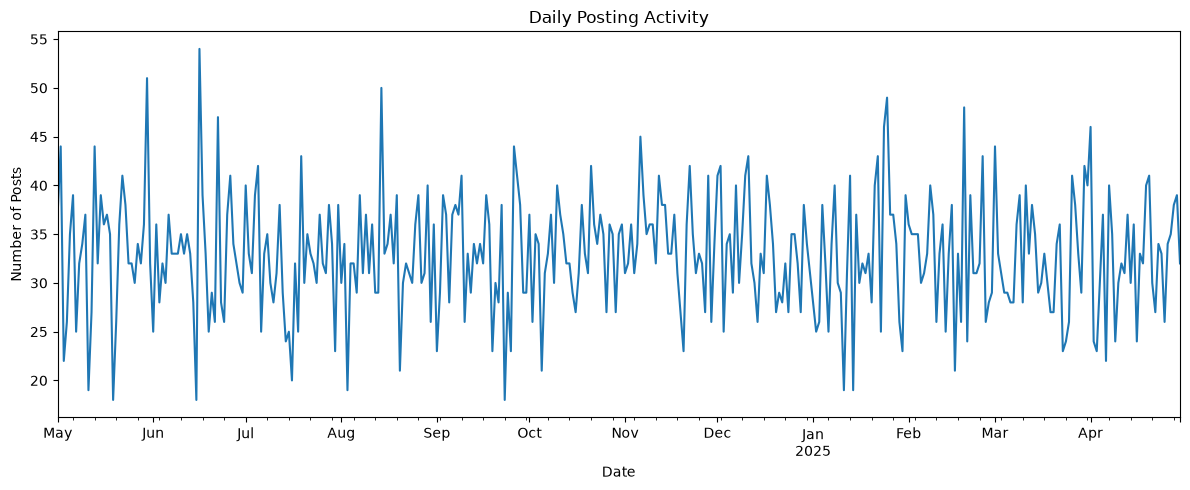

In [19]:
# Daily posting activity

plt.figure(figsize=(12, 5))

daily_posts.plot()

plt.title("Daily Posting Activity")
plt.xlabel("Date")
plt.ylabel("Number of Posts")
plt.tight_layout()
plt.show()

In [20]:
# Platform availability in the recovered dataset

platform_quality = pd.DataFrame({
    "category": ["Known platform", "Originally missing"],
    "post_count": [
        (~posts["platform_was_missing"]).sum(),
        posts["platform_was_missing"].sum()
    ]
})

platform_quality["percentage"] = (
    platform_quality["post_count"] / len(posts) * 100
).round(2)

display(platform_quality)

,category,post_count,percentage
0,Known platform,10216,85.13
1,Originally missing,1784,14.87


## Key Findings — Post Activity and Platform Usage

### Platform distribution

The cleaned dataset contains posts across five identified platforms plus an
`Unknown` category representing posts whose platform information was missing
in the recovered source.

The five known platforms are highly balanced. Facebook has the highest number
of posts with 2,074 (17.28%), followed by YouTube with 2,073 (17.27%).
Twitter, Reddit, and Instagram account for 17.08%, 16.92%, and 16.58%
respectively.

No identified platform accounts for a dominant share of activity.

### Platform data quality

1,784 of the 12,000 cleaned posts (14.87%) originally lacked platform
information. These records were retained and labeled `Unknown` rather than
assigning a platform without evidence.

Therefore, 85.13% of posts have an identified platform.

### Temporal activity

The dataset contains approximately one year of post activity. Daily posting
volume averages 32.88 posts per day, with observed daily values ranging from
18 to 54 posts.

Monthly posting volume remains broadly around 1,000 posts per month. The
highest monthly volume occurs in May 2024 with 1,038 posts, while February
2025 records the lowest monthly volume with 914 posts.

The overall pattern does not indicate a sustained long-term increase or
decrease in posting volume, although there are temporary month-to-month
fluctuations.

# 3. Engagement Analysis

This section examines user engagement through likes, shares, comments, and
the derived engagement metric.

Because invalid negative likes were converted to missing values during
cleaning, engagement statistics that depend on likes are calculated only
where the required values are available. Missing likes are not treated as
zero.

In [25]:
# Engagement data quality overview

engagement_quality = pd.DataFrame({
    "metric": [
        "Total posts",
        "Posts with known likes",
        "Posts with missing likes",
        "Posts with known engagement",
        "Posts with missing engagement"
    ],
    "count": [
        len(posts),
        posts["likes"].notna().sum(),
        posts["likes"].isna().sum(),
        posts["engagement"].notna().sum(),
        posts["engagement"].isna().sum()
    ]
})

engagement_quality["percentage"] = (
    engagement_quality["count"] / len(posts) * 100
).round(2)

display(engagement_quality)

,metric,count,percentage
0,Total posts,12000,100.00
1,Posts with known likes,9677,80.64
2,Posts with missing likes,2323,19.36
3,Posts with known engagement,9677,80.64
4,Posts with missing engagement,2323,19.36


In [26]:
# Descriptive statistics for engagement metrics

engagement_stats = posts[
    ["likes", "shares", "comments", "engagement"]
].describe().T

display(engagement_stats)

,count,mean,std,min,25%,50%,75%,max
likes,9677.0,2493.505115,1438.286521,0.0,1240.0,2502.0,3724.0,5000.0
shares,12000.0,1007.167167,575.072282,0.0,510.0,1018.0,1501.0,2000.0
comments,12000.0,504.345750,288.684160,0.0,253.0,503.0,755.0,1000.0
engagement,9677.0,4006.411388,1580.698537,153.0,2748.0,4009.0,5242.0,7893.0


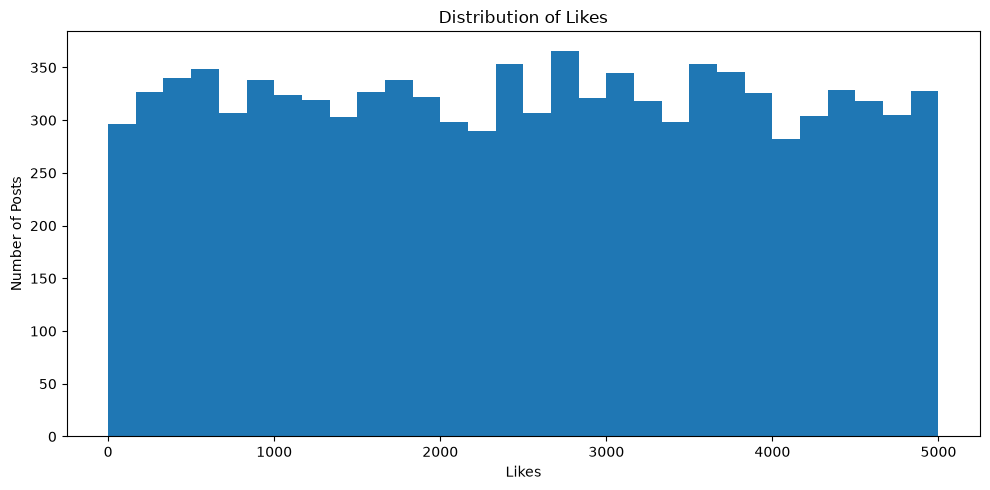

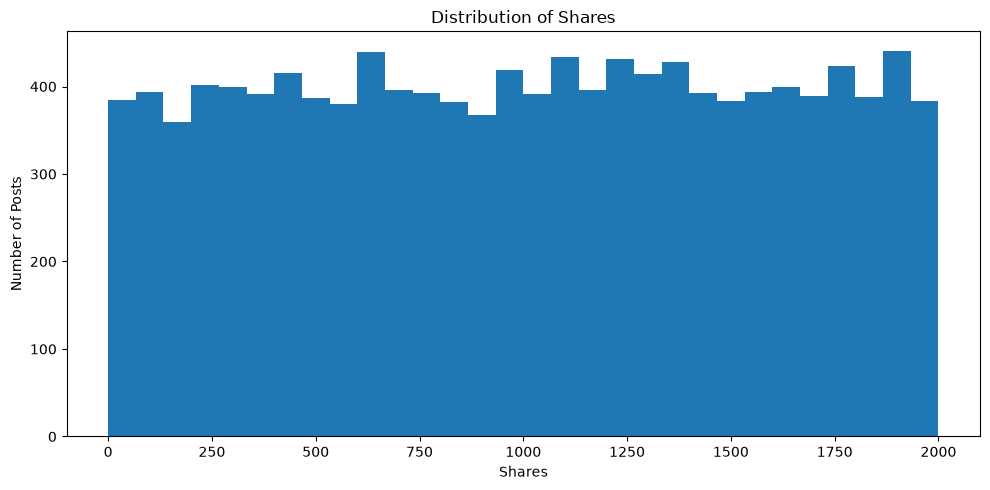

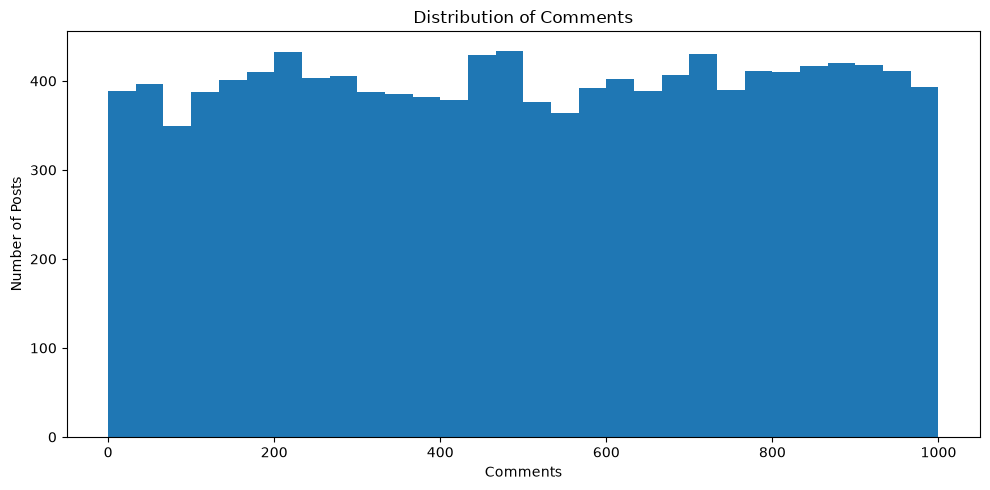

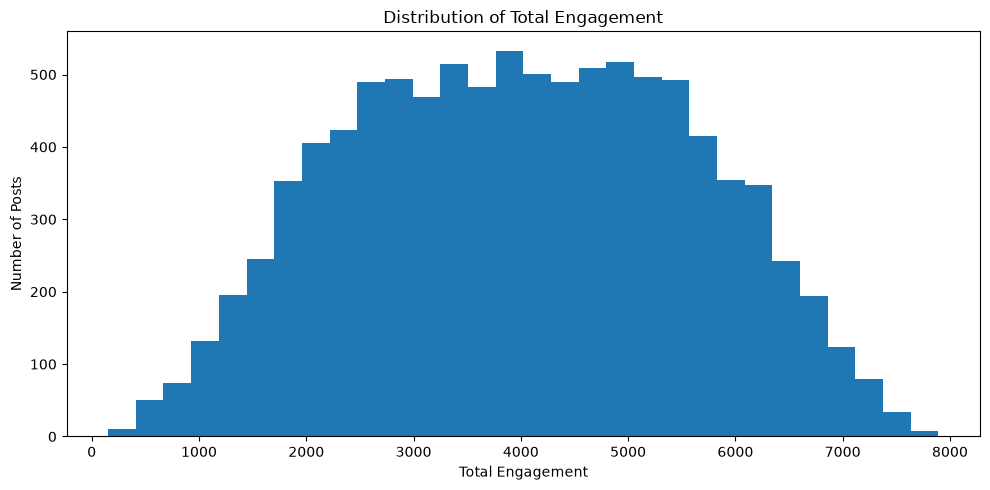

In [27]:
# Distribution of engagement metrics

figures = {
    "Likes": posts["likes"].dropna(),
    "Shares": posts["shares"].dropna(),
    "Comments": posts["comments"].dropna(),
    "Total Engagement": posts["engagement"].dropna()
}

for title, values in figures.items():
    plt.figure(figsize=(10, 5))
    plt.hist(values, bins=30)
    plt.title(f"Distribution of {title}")
    plt.xlabel(title)
    plt.ylabel("Number of Posts")
    plt.tight_layout()
    plt.show()

## Key Findings — Engagement Distribution

### Engagement data completeness

Of the 12,000 cleaned posts, 9,677 (80.64%) have known likes and therefore
known total engagement. The remaining 2,323 posts (19.36%) have unavailable
likes. These posts are retained in the dataset but are excluded from analyses
that require a complete engagement value rather than being treated as having
zero engagement.

### Likes

Among posts with available likes, the mean is approximately 2,493.5 and the
median is 2,502. Likes range from 0 to 5,000. The close relationship between
the mean and median indicates that the observed likes distribution is not
strongly shifted by a small number of extreme values.

### Shares and comments

Shares have a mean of approximately 1,007.2 and a median of 1,018, while
comments have a mean of approximately 504.3 and a median of 503.

### Total engagement

For posts with known likes, total engagement has a mean of approximately
4,006.4 and a median of 4,009. Values range from 153 to 7,893.

The relatively close mean and median indicate that total engagement is not
strongly dominated by a small number of extreme observations in this dataset.

# 4. Engagement by Platform

This section compares engagement behavior across identified platforms.

Only posts with known total engagement are included in engagement-based
statistics. Posts whose likes were unavailable are not treated as zero.

The `Unknown` platform category is retained separately because the original
platform information could not be recovered.

In [31]:
# Engagement by platform

platform_engagement = (
    posts.groupby("platform")
    .agg(
        post_count=("post_id", "count"),
        posts_with_known_engagement=("engagement", "count"),
        avg_likes=("likes", "mean"),
        median_likes=("likes", "median"),
        avg_shares=("shares", "mean"),
        median_shares=("shares", "median"),
        avg_comments=("comments", "mean"),
        median_comments=("comments", "median"),
        avg_engagement=("engagement", "mean"),
        median_engagement=("engagement", "median"),
    )
    .reset_index()
)

# Calculate percentage of posts with usable engagement
platform_engagement["known_engagement_pct"] = (
    platform_engagement["posts_with_known_engagement"]
    / platform_engagement["post_count"]
    * 100
).round(2)

# Round numerical metrics for readability
numeric_columns = [
    "avg_likes",
    "median_likes",
    "avg_shares",
    "median_shares",
    "avg_comments",
    "median_comments",
    "avg_engagement",
    "median_engagement",
]

platform_engagement[numeric_columns] = (
    platform_engagement[numeric_columns].round(2)
)

display(
    platform_engagement.sort_values(
        "avg_engagement",
        ascending=False
    )
)

,platform,post_count,posts_with_known_engagement,avg_likes,median_likes,avg_shares,median_shares,avg_comments,median_comments,avg_engagement,median_engagement,known_engagement_pct
5,YouTube,2073,1664,2528.33,2619.5,1011.83,1017.0,504.38,498.0,4048.88,4094.5,80.27
1,Instagram,1989,1597,2494.51,2495.0,1040.84,1049.0,499.80,498.0,4040.06,3982.0,80.29
0,Facebook,2074,1685,2526.55,2573.0,984.17,993.5,506.94,504.0,4014.40,4021.0,81.24
2,Reddit,2031,1663,2487.80,2496.0,1002.23,1016.0,511.18,513.0,4001.24,4006.0,81.88
4,Unknown,1784,1436,2480.82,2428.5,998.61,1005.5,496.54,498.5,3970.31,3978.0,80.49
3,Twitter,2049,1632,2439.87,2443.5,1005.39,1022.0,506.13,504.0,3958.98,3953.0,79.65


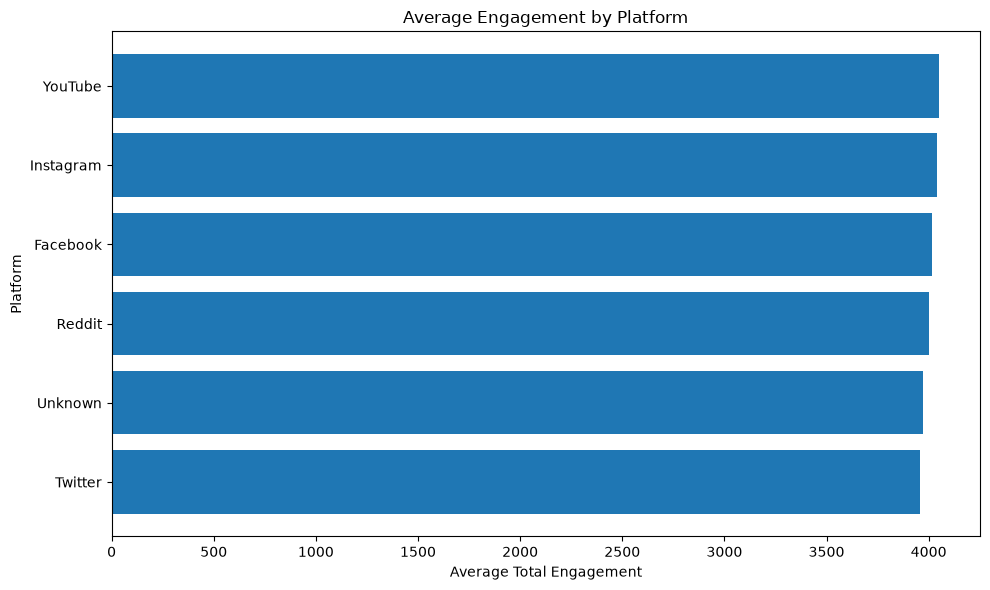

In [32]:
# Average engagement by platform

plot_data = platform_engagement.sort_values("avg_engagement")

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["platform"],
    plot_data["avg_engagement"]
)

plt.title("Average Engagement by Platform")
plt.xlabel("Average Total Engagement")
plt.ylabel("Platform")
plt.tight_layout()
plt.show()

In [33]:
# Average likes, shares, and comments by platform

component_data = (
    posts.groupby("platform")[
        ["likes", "shares", "comments"]
    ]
    .mean()
    .round(2)
)

display(component_data)

,likes,shares,comments
platform,,,
Facebook,2526.55,984.17,506.94
Instagram,2494.51,1040.84,499.80
Reddit,2487.80,1002.23,511.18
Twitter,2439.87,1005.39,506.13
Unknown,2480.82,998.61,496.54
YouTube,2528.33,1011.83,504.38


## Key Findings — Engagement by Platform

Average engagement is relatively similar across all platform categories.

Among the identified platforms, YouTube has the highest average total
engagement at approximately 4,048.5, followed closely by Instagram at
4,040.1 and Facebook at 4,014.4. Reddit averages approximately 4,001.2,
while Twitter has the lowest average among identified platforms at
approximately 3,959.0.

The relatively narrow range between platforms suggests that platform choice
alone is not a strong differentiator of average engagement in this dataset.

The average likes, shares, and comments show a similar pattern. Facebook and
YouTube have comparatively high average likes, while Instagram has the
highest average shares. Comment averages remain close across platforms.

The `Unknown` category has slightly lower average engagement than the
identified platforms, but this should not be interpreted as a platform
effect because these posts have missing original platform information.

# 5. User Influence and Engagement

This section investigates whether audience size, represented by follower
count, is associated with posting activity and engagement.

User-level statistics are calculated from the cleaned posts and joined with
the cleaned user dataset.

In [34]:
# User-level posting and engagement summary

user_post_summary = (
    posts.groupby("user_id")
    .agg(
        post_count=("post_id", "count"),
        posts_with_known_engagement=("engagement", "count"),
        avg_engagement=("engagement", "mean"),
        median_engagement=("engagement", "median"),
        avg_likes=("likes", "mean"),
        avg_shares=("shares", "mean"),
        avg_comments=("comments", "mean"),
    )
    .reset_index()
)

user_analysis = users.merge(
    user_post_summary,
    on="user_id",
    how="left"
)

display(user_analysis.head())

,user_id,location,language,account_created,follower_count,post_count,posts_with_known_engagement,avg_engagement,median_engagement,avg_likes,avg_shares,avg_comments
0,user_guglt5jp,"Berlin, Germany",ja,2023-10-23,38963,9,7,4177.142857,3938.0,2459.857143,1149.888889,533.888889
1,user_b1p3wz81,"Munich, Germany",zh,2023-05-06,24644,8,5,3621.600000,3847.0,2668.600000,853.250000,330.500000
2,user_jm2grmis,"Dubai, UAE",en,2023-01-03,45842,5,3,6058.000000,5723.0,4793.333333,841.200000,621.000000
3,user_ykoqww5l,"Paris, France",fr,2023-10-11,665,7,6,3361.000000,3492.0,1719.500000,1177.142857,515.857143
4,user_3zzvv8vp,"Los Angeles, USA",ru,2023-05-23,42908,13,11,4433.545455,4581.0,3248.909091,861.384615,517.076923


In [35]:
# Correlation between follower count and engagement-related metrics

correlation_data = user_analysis[
    [
        "follower_count",
        "post_count",
        "avg_engagement",
        "avg_likes",
        "avg_shares",
        "avg_comments",
    ]
].corr()

display(
    correlation_data["follower_count"]
    .sort_values(ascending=False)
    .to_frame(name="correlation_with_followers")
)

,correlation_with_followers
follower_count,1.000000
avg_likes,0.011493
avg_comments,-0.000513
avg_engagement,-0.004211
post_count,-0.007717
avg_shares,-0.042770


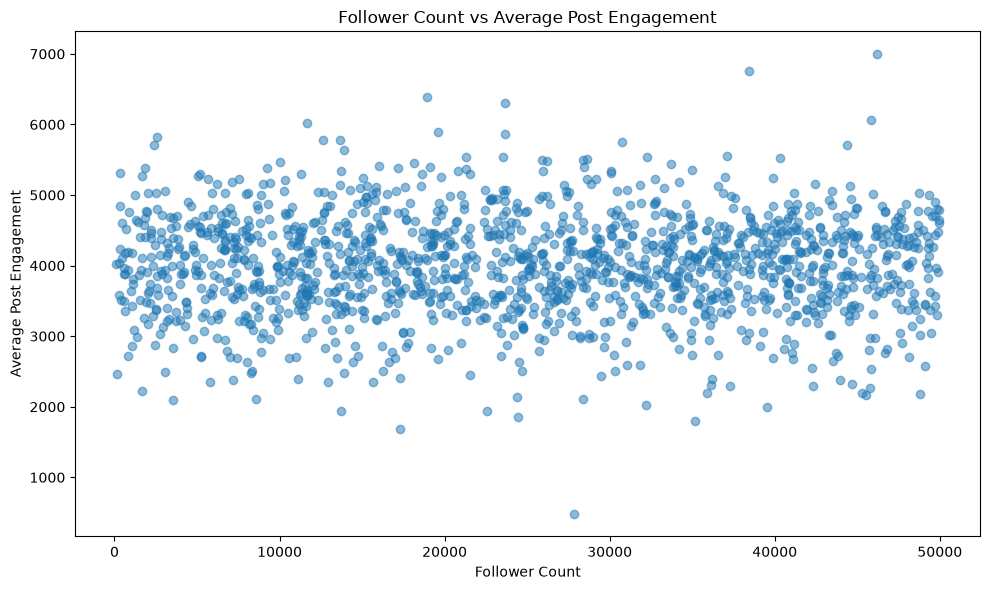

In [36]:
# Follower count vs average engagement

plot_data = user_analysis.dropna(
    subset=["follower_count", "avg_engagement"]
)

plt.figure(figsize=(10, 6))

plt.scatter(
    plot_data["follower_count"],
    plot_data["avg_engagement"],
    alpha=0.5
)

plt.title("Follower Count vs Average Post Engagement")
plt.xlabel("Follower Count")
plt.ylabel("Average Post Engagement")
plt.tight_layout()
plt.show()

In [37]:
# Divide users into follower-count quartiles

user_analysis["follower_tier"] = pd.qcut(
    user_analysis["follower_count"],
    q=4,
    labels=[
        "Q1 - Lowest",
        "Q2",
        "Q3",
        "Q4 - Highest"
    ]
)

tier_analysis = (
    user_analysis
    .groupby("follower_tier", observed=True)
    .agg(
        users=("user_id", "count"),
        avg_followers=("follower_count", "mean"),
        avg_posts=("post_count", "mean"),
        avg_engagement=("avg_engagement", "mean"),
    )
    .reset_index()
)

tier_analysis = tier_analysis.round(2)

display(tier_analysis)

,follower_tier,users,avg_followers,avg_posts,avg_engagement
0,Q1 - Lowest,375,6658.28,8.12,4000.15
1,Q2,375,18718.30,7.87,4018.85
2,Q3,375,31050.34,8.09,3979.06
3,Q4 - Highest,375,43429.15,7.93,4002.18


# 6. Content and Text Analysis

This section examines the characteristics of post text and investigates
whether text length is associated with engagement.

Missing text is retained as missing rather than replaced with fabricated
content.

In [42]:
# Text availability and length

posts["text_length"] = posts["text_content"].str.len()

text_quality = pd.DataFrame({
    "metric": [
        "Total posts",
        "Posts with text",
        "Posts with missing text",
        "Average text length",
        "Median text length",
        "Minimum text length",
        "Maximum text length"
    ],
    "value": [
        len(posts),
        posts["text_content"].notna().sum(),
        posts["text_content"].isna().sum(),
        posts["text_length"].mean(),
        posts["text_length"].median(),
        posts["text_length"].min(),
        posts["text_length"].max()
    ]
})

text_quality["value"] = text_quality["value"].round(2)

display(text_quality)

,metric,value
0,Total posts,12000.00
1,Posts with text,10240.00
2,Posts with missing text,1760.00
3,Average text length,117.63
4,Median text length,118.00
5,Minimum text length,6.00
6,Maximum text length,172.00


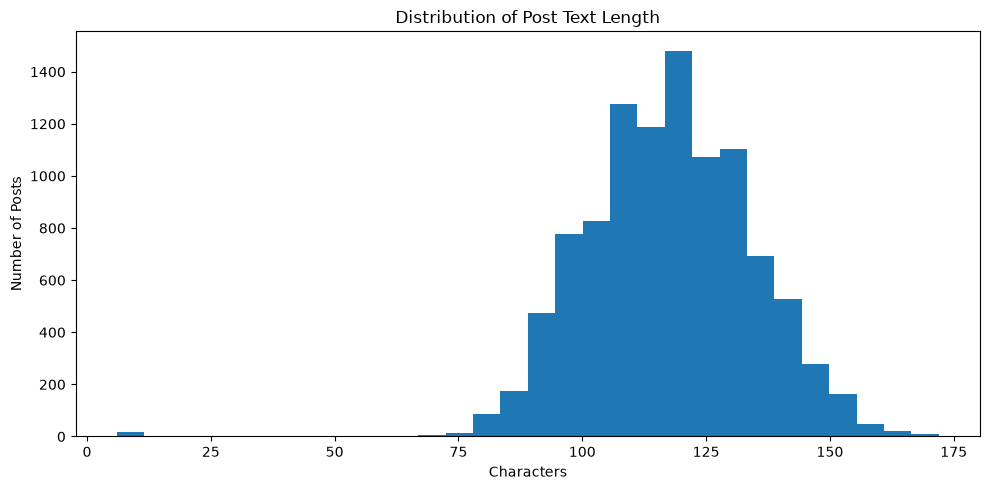

In [43]:
# Distribution of text length

plt.figure(figsize=(10, 5))

plt.hist(
    posts["text_length"].dropna(),
    bins=30
)

plt.title("Distribution of Post Text Length")
plt.xlabel("Characters")
plt.ylabel("Number of Posts")
plt.tight_layout()
plt.show()

In [44]:
# Text length vs engagement

text_engagement = posts.dropna(
    subset=["text_length", "engagement"]
)

print(
    "Correlation between text length and engagement:",
    round(
        text_engagement["text_length"]
        .corr(text_engagement["engagement"]),
        4
    )
)

Correlation between text length and engagement: -0.0145


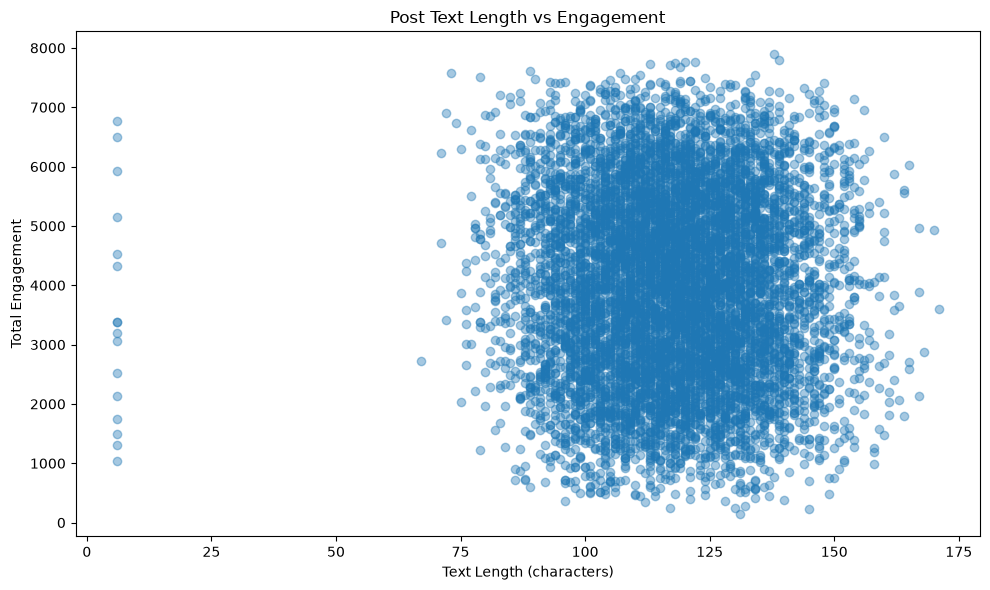

In [45]:
# Scatter plot: text length vs engagement

plt.figure(figsize=(10, 6))

plt.scatter(
    text_engagement["text_length"],
    text_engagement["engagement"],
    alpha=0.4
)

plt.title("Post Text Length vs Engagement")
plt.xlabel("Text Length (characters)")
plt.ylabel("Total Engagement")
plt.tight_layout()
plt.show()

## Key Findings — Content and Text

Of the 12,000 cleaned posts, 10,240 (85.33%) contain text, while 1,760
(14.67%) have missing text. Missing text was retained as missing rather than
replaced with fabricated content.

Among posts containing text, the average text length is approximately 117.6
characters and the median is 118 characters. Observed text length ranges from
6 to 172 characters.

The correlation between text length and total engagement is -0.0145, which is
effectively zero. The scatter plot also shows no clear visual relationship
between text length and engagement.

Therefore, within this dataset, post length does not appear to be a meaningful
linear predictor of engagement.

# 7. Anomaly and Outlier Analysis

This section identifies both data-quality anomalies and statistically
unusual observations.

A statistical outlier is not automatically considered an error. Observations
are retained unless there is evidence that they are invalid or corrupted.

In [49]:
# IQR-based outlier analysis for engagement

engagement_values = posts["engagement"].dropna()

q1 = engagement_values.quantile(0.25)
q3 = engagement_values.quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

engagement_outliers = posts[
    posts["engagement"].notna()
    & (
        (posts["engagement"] < lower_bound)
        | (posts["engagement"] > upper_bound)
    )
].copy()

print("Q1:", round(q1, 2))
print("Q3:", round(q3, 2))
print("IQR:", round(iqr, 2))
print("Lower bound:", round(lower_bound, 2))
print("Upper bound:", round(upper_bound, 2))
print("Number of engagement outliers:", len(engagement_outliers))
print(
    "Percentage of known-engagement posts:",
    round(len(engagement_outliers) / len(engagement_values) * 100, 2),
)

display(
    engagement_outliers[
        [
            "post_id",
            "platform",
            "likes",
            "shares",
            "comments",
            "engagement",
        ]
    ]
    .sort_values("engagement", ascending=False)
    .head(20)
)

Q1: 2748.0
Q3: 5242.0
IQR: 2494.0
Lower bound: -993.0
Upper bound: 8983.0
Number of engagement outliers: 0
Percentage of known-engagement posts: 0.0


,post_id,platform,likes,shares,comments,engagement


In [50]:
# IQR-based outlier analysis for likes

likes_values = posts["likes"].dropna()

likes_q1 = likes_values.quantile(0.25)
likes_q3 = likes_values.quantile(0.75)
likes_iqr = likes_q3 - likes_q1

likes_upper = likes_q3 + 1.5 * likes_iqr

likes_outliers = posts[
    posts["likes"].notna()
    & (posts["likes"] > likes_upper)
].copy()

print("Likes Q1:", round(likes_q1, 2))
print("Likes Q3:", round(likes_q3, 2))
print("Likes IQR:", round(likes_iqr, 2))
print("Likes upper bound:", round(likes_upper, 2))
print("Number of high-like outliers:", len(likes_outliers))

display(
    likes_outliers[
        [
            "post_id",
            "platform",
            "likes",
            "shares",
            "comments",
            "engagement",
        ]
    ]
    .sort_values("likes", ascending=False)
    .head(20)
)

Likes Q1: 1240.0
Likes Q3: 3724.0
Likes IQR: 2484.0
Likes upper bound: 7450.0
Number of high-like outliers: 0


,post_id,platform,likes,shares,comments,engagement


In [51]:
# Zero-value engagement checks

zero_metrics = pd.DataFrame({
    "metric": ["likes", "shares", "comments"],
    "zero_count": [
        (posts["likes"] == 0).sum(),
        (posts["shares"] == 0).sum(),
        (posts["comments"] == 0).sum(),
    ]
})

display(zero_metrics)

,metric,zero_count
0,likes,1
1,shares,5
2,comments,13


## Key Findings — Anomaly and Outlier Analysis

The cleaned dataset was evaluated using the interquartile range (IQR) method
to identify statistically unusual observations.

No posts were classified as engagement outliers using the 1.5 × IQR rule.
Similarly, no posts exceeded the IQR-based upper threshold for likes.

This indicates that the observed distributions of likes and total engagement
are relatively bounded and do not contain statistically extreme observations
under this outlier definition.

A small number of posts have zero engagement components: 1 post has zero
likes, 5 posts have zero shares, and 13 posts have zero comments. These values
are not treated as errors because zero is a logically valid engagement value.

The major anomalies in the original recovered dataset were data-quality
issues rather than statistical outliers. These included duplicate post
records, negative likes, missing platform values, missing likes, and corrupted
text. The invalid negative likes and duplicate records were addressed during
cleaning, while genuine missing values were retained rather than fabricated.

# 8. Cross-Analysis and Final Insights

This section combines the user, posting, engagement, and content analyses to
identify the strongest relationships and patterns in the recovered Social
Engine dataset.

In [54]:
# Final cross-analysis summary

print("FINAL DATASET SUMMARY")
print("=" * 60)

print("Users:", len(users))
print("Posts:", len(posts))
print("Platforms:", posts["platform"].nunique())
print("Languages:", users["language"].nunique())
print("Locations:", users["location"].nunique())

known_engagement = posts["engagement"].notna().sum()

print(
    "Posts with known engagement:",
    known_engagement,
    f"({known_engagement / len(posts) * 100:.2f}%)"
)

missing_engagement = len(posts) - known_engagement

print(
    "Posts with missing engagement:",
    missing_engagement,
    f"({missing_engagement / len(posts) * 100:.2f}%)"
)

print("\nCORRELATIONS")
print("=" * 60)

follower_corr = (
    user_analysis[["follower_count", "avg_engagement"]]
    .corr()
    .iloc[0, 1]
)

text_corr = (
    posts[["text_length", "engagement"]]
    .dropna()
    .corr()
    .iloc[0, 1]
)

print("Follower count vs average engagement:", round(follower_corr, 4))
print("Text length vs engagement:", round(text_corr, 4))

print("\nTOP PLATFORMS BY AVERAGE ENGAGEMENT")
print("=" * 60)

display(
    platform_engagement[
        ["platform", "post_count", "avg_engagement"]
    ]
    .sort_values("avg_engagement", ascending=False)
    .reset_index(drop=True)
)

print("\nPOST VOLUME BY MONTH")
print("=" * 60)

display(monthly_posts.to_frame())

FINAL DATASET SUMMARY
Users: 1500
Posts: 12000
Platforms: 6
Languages: 10
Locations: 33
Posts with known engagement: 9677 (80.64%)
Posts with missing engagement: 2323 (19.36%)

CORRELATIONS
Follower count vs average engagement: -0.0042
Text length vs engagement: -0.0145

TOP PLATFORMS BY AVERAGE ENGAGEMENT


,platform,post_count,avg_engagement
0,YouTube,2073,4048.88
1,Instagram,1989,4040.06
2,Facebook,2074,4014.40
3,Reddit,2031,4001.24
4,Unknown,1784,3970.31
5,Twitter,2049,3958.98



POST VOLUME BY MONTH


,post_count
timestamp,
2024-05-31,1038
2024-06-30,979
2024-07-31,996
2024-08-31,1015
2024-09-30,974
2024-10-31,1029
2024-11-30,1025
2024-12-31,1035
2025-01-31,1007


## Final EDA Insights

### 1. The dataset is broadly balanced across platforms

The recovered dataset contains posts across Facebook, YouTube, Twitter,
Reddit, Instagram, and an Unknown category. The identified platforms have
similar post volumes, while 14.87% of posts have unavailable original
platform information.

### 2. Platform choice does not strongly differentiate engagement

Average engagement is relatively close across the identified platforms.
YouTube has the highest observed average engagement at approximately 4,048.5,
followed by Instagram at approximately 4,040.1 and Facebook at approximately
4,014.4.

The relatively narrow range suggests that platform alone is not a strong
differentiator of average engagement in this dataset.

### 3. Follower count has almost no relationship with engagement

The correlation between follower count and average post engagement is
approximately -0.0042.

This is effectively zero, indicating that users with larger audiences do not
necessarily receive higher engagement per post in the recovered dataset.

### 4. Post length has almost no relationship with engagement

The correlation between text length and engagement is approximately -0.0145.

This is also effectively zero. The available evidence therefore does not
support the conclusion that longer posts receive meaningfully higher
engagement.

### 5. Posting activity is relatively stable over the year

Monthly posting volume remains close to approximately 1,000 posts per month.
There is some month-to-month variation, with February showing the lowest
monthly volume, but there is no sustained increasing or decreasing trend.

### 6. Engagement data is incomplete and must be interpreted carefully

Of the 12,000 cleaned posts, 9,677 have known likes and therefore known total
engagement. The remaining 2,323 posts have unavailable likes.

These posts were retained rather than treating missing likes as zero.
Engagement-based analysis therefore uses only observations where engagement
can be calculated reliably.

### 7. The major problems were data-quality problems, not extreme values

The original recovered dataset contained duplicate records, negative likes,
missing fields, mixed timestamp formats, and corrupted text.

After cleaning and validation, duplicate post IDs, negative engagement values,
invalid timestamps, HTML corruption, and other identified formatting issues
were resolved.

No IQR-based statistical outliers were detected for likes or total
engagement in the cleaned data.